# BTS T-100 Segment Data — Departures by Aircraft Type and Distance

Derives annual US departure counts by fleet segment from `T_SCHEDULE_T2_2024.csv`
in `processing/usdot/data/` (BTS Form 41, Schedule T-2, year 2024).

Each row in that file covers one carrier × quarter × aircraft type × service class.
We keep `SERVICE_CLASS = 'F'` (scheduled passenger) and use `CARRIER_REGION` to
separate domestic (`D`) from international (`A`/`I`).
Average stage length is derived as `miles_flown / departures` and used to split
domestic narrowbody from transcon narrowbody.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../../processing/usdot/data")

# Carrier regions
DOMESTIC_REGIONS = {"D", "L", "P"}  # D=domestic, L=local/commuter, P=peripheral
INTERNATIONAL_REGIONS = {"A", "I"}  # A=Atlantic, I=international

KM_PER_MI = 1.60934

## Aircraft type classification

In [2]:
# BTS AIRCRAFT_TYPE numeric codes (verified against L_AIRCRAFT_TYPE.csv + 2024 T-100 data)
A320_FAMILY = {
    694: "A320",
    698: "A319",
    699: "A321",
    719: "A319neo",
    721: "A321neo",
    722: "A320neo",
}

B737_FAMILY = {
    612: "B737-700/MAX7",
    614: "B737-800",
    634: "B737-900",
    838: "B737 MAX 8",
    839: "B737 MAX 9",
    885: "B737 MAX 10",
    888: "B737-900ER",
}

NARROWBODY_CODES = set(A320_FAMILY) | set(B737_FAMILY)

WIDEBODY_CODES = {
    622: "B757-200",
    623: "B757-300",
    624: "B767-400ER",
    625: "B767-200ER",
    626: "B767-300ER",
    627: "B777-200ER",
    637: "B777-300ER",
    887: "B787-8",
    889: "B787-9",
    837: "B787-10",
    696: "A330-200",
    687: "A330-300",
    339: "A330-900neo",
    359: "A350-900",
    335: "A350-1000",
    882: "A380-800",
}

REGIONAL_CODES = {
    673: "E175",
    677: "E170",
    678: "E190",
    675: "E145",
    676: "E140",
    674: "E135",
    638: "CRJ900",
    631: "CRJ700",
    530: "CRJ550",
    657: "CRJ705",
    629: "CRJ200",
}

# Distance threshold (statute miles — miles_flown / departures)
TRANSCON_THRESHOLD_MI = 1_500
print(
    f"Transcon threshold: > {TRANSCON_THRESHOLD_MI} mi  ({TRANSCON_THRESHOLD_MI * KM_PER_MI:.0f} km)"
)

Transcon threshold: > 1500 mi  (2414 km)


## Load and prepare data

In [3]:
df = pd.read_csv(DATA_DIR / "T_SCHEDULE_T2_2024.csv")
df.columns = df.columns.str.strip()

# Scheduled passenger service only, carrier groups 2–3, with actual departures
# Group 2: regional express/code-share operators; Group 3: large certified passenger carriers
df = df[
    (df["SERVICE_CLASS"] == "F")
    & (df["CARRIER_GROUP_NEW"].isin({2, 3}))
    & (df["REV_ACRFT_DEP_PERF_510"] > 0)
    & (df["REV_ACRFT_MILES_FLOWN_410"] > 0)
].copy()

df["avg_stage_mi"] = df["REV_ACRFT_MILES_FLOWN_410"] / df["REV_ACRFT_DEP_PERF_510"]

print(f"Rows after filter: {len(df):,}")
print(f"Total departures (all types): {df['REV_ACRFT_DEP_PERF_510'].sum():,.0f}")
df[
    [
        "UNIQUE_CARRIER_NAME",
        "CARRIER_GROUP_NEW",
        "CARRIER_REGION",
        "AIRCRAFT_TYPE",
        "REV_ACRFT_DEP_PERF_510",
        "avg_stage_mi",
    ]
].head(10)

Rows after filter: 635
Total departures (all types): 6,336,851


,UNIQUE_CARRIER_NAME,CARRIER_GROUP_NEW,CARRIER_REGION,AIRCRAFT_TYPE,REV_ACRFT_DEP_PERF_510,avg_stage_mi
0,Southwest Airlines Co.,3,D,612,169408.0,683.470822
5,Southwest Airlines Co.,3,D,614,82822.0,784.092149
10,Southwest Airlines Co.,3,D,838,89115.0,824.841744
15,Southwest Airlines Co.,3,L,612,4099.0,1032.198829
18,Southwest Airlines Co.,3,L,614,1627.0,1150.241549
21,Southwest Airlines Co.,3,L,838,2908.0,1043.759285
24,Horizon Air,2,D,673,18515.0,497.621928
29,Hawaiian Airlines Inc.,3,D,608,13614.0,139.719113
34,Hawaiian Airlines Inc.,3,D,696,2859.0,2881.104232
40,Hawaiian Airlines Inc.,3,D,721,2383.0,2453.946706


## (Optional) Explore aircraft type codes present in the data

In [4]:
lookup_path = DATA_DIR / "L_AIRCRAFT_TYPE.csv"

if lookup_path.exists():
    lookup = pd.read_csv(lookup_path, names=["Code", "Description"], skiprows=1)
    summary = (
        df.groupby("AIRCRAFT_TYPE")["REV_ACRFT_DEP_PERF_510"]
        .sum()
        .reset_index()
        .merge(lookup, left_on="AIRCRAFT_TYPE", right_on="Code", how="left")
        .sort_values("REV_ACRFT_DEP_PERF_510", ascending=False)
    )
    print(summary.to_string(index=False))
else:
    print("L_AIRCRAFT_TYPE.csv not found — showing raw codes only")
    print(
        df.groupby("AIRCRAFT_TYPE")["REV_ACRFT_DEP_PERF_510"]
        .sum()
        .sort_values(ascending=False)
    )

 AIRCRAFT_TYPE  REV_ACRFT_DEP_PERF_510  Code                   Description
           614                852220.0   614                Boeing 737-800
           673                832618.0   673               Embraer ERJ-175
           612                593665.0   612    Boeing 737-700/700LR/Max 7
           694                464642.0   694 Airbus Industrie A320-100/200
           699                454244.0   699      Airbus Industrie A321/Lr
           838                432694.0   838           Boeing B737 Max 800
           888                352065.0   888              Boeing 737-900ER
           638                330026.0   638              Canadair CRJ 900
           698                307897.0   698         Airbus Industrie A319
           721                187057.0   721    Airbus Industrie A321-200n
           722                180983.0   722    Airbus Industrie A320-200n
           631                171430.0   631               Canadair RJ-700
           608           

## Classify into fleet segments

In [5]:
def classify(row):
    code = row["AIRCRAFT_TYPE"]
    region = row["CARRIER_REGION"]
    dist = row["avg_stage_mi"]

    if region in DOMESTIC_REGIONS:
        if code in NARROWBODY_CODES:
            return (
                "transcon_narrowbody"
                if dist > TRANSCON_THRESHOLD_MI
                else "domestic_narrowbody"
            )
        if code in REGIONAL_CODES:
            return "regional_jet"
    if region in INTERNATIONAL_REGIONS and code in WIDEBODY_CODES:
        return "international_widebody"
    return None


df["segment"] = df.apply(classify, axis=1)

all_segments = (
    df.dropna(subset=["segment"])
    .groupby("segment")["REV_ACRFT_DEP_PERF_510"]
    .sum()
    .rename("annual_departures")
    .astype(int)
    .reset_index()
)

print("Annual departures by segment (2024, T-100 Schedule T-2):")
print(all_segments.to_string(index=False))

annual_departures = dict(
    zip(all_segments["segment"], all_segments["annual_departures"])
)
print("\nannual_departures =", annual_departures)

Annual departures by segment (2024, T-100 Schedule T-2):
               segment  annual_departures
   domestic_narrowbody            3614695
international_widebody             119703
          regional_jet            1751816
   transcon_narrowbody             344580

annual_departures = {'domestic_narrowbody': 3614695, 'international_widebody': 119703, 'regional_jet': 1751816, 'transcon_narrowbody': 344580}


## Average stage length per segment (for reference)

In [6]:
seg_df = df.dropna(subset=["segment"])
avg_dist = (
    seg_df.groupby("segment")
    .apply(
        lambda g: pd.Series(
            {
                "avg_stage_mi": np.average(
                    g["avg_stage_mi"], weights=g["REV_ACRFT_DEP_PERF_510"]
                ),
                "avg_stage_km": np.average(
                    g["avg_stage_mi"], weights=g["REV_ACRFT_DEP_PERF_510"]
                )
                * KM_PER_MI,
            }
        ),
        include_groups=False,
    )
    .round(0)
)
print(avg_dist.to_string())

                        avg_stage_mi  avg_stage_km
segment                                           
domestic_narrowbody            912.0        1468.0
international_widebody        4335.0        6977.0
regional_jet                   455.0         732.0
transcon_narrowbody           1779.0        2863.0


## Sanity-check plot

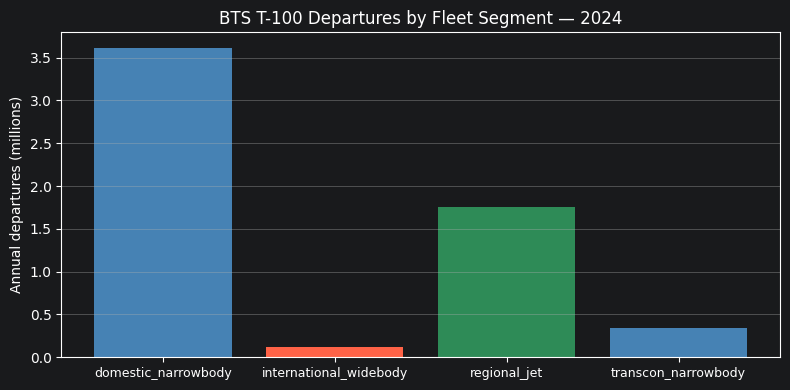

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    all_segments["segment"],
    all_segments["annual_departures"] / 1e6,
    color=["steelblue", "tomato", "seagreen"][: len(all_segments)],
)
ax.set_ylabel("Annual departures (millions)")
ax.set_title("BTS T-100 Departures by Fleet Segment — 2024")
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="y", linewidth=0.5)
plt.tight_layout()
plt.savefig("t100_departures_by_segment.pdf", bbox_inches="tight")
plt.show()